<a href="https://colab.research.google.com/github/Mooketsi324/Dataset-for-programing-for-data-analytics/blob/main/POE_PDAN8411.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install Google Chrome (not chromium — chromium's apt package is broken in Colab)
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add - > /dev/null 2>&1
!echo "deb http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list
!apt-get update --quiet
!apt-get install -y google-chrome-stable --quiet

# Install Selenium + webdriver-manager (auto-downloads the matching driver)
!pip install selenium webdriver-manager --quiet

Get:1 http://dl.google.com/linux/chrome/deb stable InRelease [2,548 B]
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://dl.google.com/linux/chrome/deb stable/main amd64 Packages [1,412 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,960 B in 1s (3,136 B/s)
Reading package lists...
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skippi

In [5]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import time

options = Options()
options.add_argument('--headless=new')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--disable-gpu')
options.add_argument('--window-size=1920,1080')

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.hellopeter.com/discovery-health/reviews"
driver.get(url)

time.sleep(6)

with open('rendered_page.html', 'w', encoding='utf-8') as f:
    f.write(driver.page_source)

print("Page title:", driver.title)
print("Page length (characters):", len(driver.page_source))

Page title: 
Page length (characters): 38474


In [6]:
with open('rendered_page.html', 'r', encoding='utf-8') as f:
    content = f.read()

# Check for common blocking indicators
for keyword in ['captcha', 'Access Denied', 'blocked', 'Cloudflare', 'Just a moment']:
    if keyword.lower() in content.lower():
        print(f"⚠️ Found possible blocking indicator: '{keyword}'")

# Check for review-related content
for keyword in ['review', 'Discovery', 'rating', 'star']:
    count = content.lower().count(keyword.lower())
    print(f"'{keyword}' appears {count} times")

# Show a chunk of the middle of the page so we can eyeball it
print("\n--- Sample content ---")
print(content[15000:16500])

⚠️ Found possible blocking indicator: 'captcha'
'review' appears 2 times
'Discovery' appears 2 times
'rating' appears 0 times
'star' appears 0 times

--- Sample content ---
opper.js v1.0.0
 * https://github.com/fengyuanchen/cropperjs
 *
 * Copyright (c) 2017 Fengyuan Chen
 * Released under the MIT license
 *
 * Date: 2017-09-03T12:52:44.102Z
 */.cropper-container{direction:ltr;font-size:0;line-height:0;position:relative;-ms-touch-action:none;touch-action:none;-webkit-user-select:none;-moz-user-select:none;-ms-user-select:none;user-select:none}.cropper-container img{display:block;height:100%;image-orientation:0deg;max-height:none!important;max-width:none!important;min-height:0!important;min-width:0!important;width:100%}.cropper-canvas,.cropper-crop-box,.cropper-drag-box,.cropper-modal,.cropper-wrap-box{bottom:0;left:0;position:absolute;right:0;top:0}.cropper-wrap-box{overflow:hidden}.cropper-drag-box{background-color:#fff;opacity:0}.cropper-modal{background-color:#000;opacity:.5}.croppe

In [8]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3506ab2544788d057e7a84141439eae3'

!pip install kaggle --quiet
!kaggle datasets download -d kundanbedmutha/customer-sentiment-dataset
!unzip -o customer-sentiment-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/kundanbedmutha/customer-sentiment-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 289k/289k [00:00<00:00, 113MB/s]

Archive:  customer-sentiment-dataset.zip
  inflating: Customer_Sentiment.csv  


In [9]:
import pandas as pd

df = pd.read_csv('Customer_Sentiment.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (25000, 13)

Columns: ['customer_id', 'gender', 'age_group', 'region', 'product_category', 'purchase_channel', 'platform', 'customer_rating', 'review_text', 'sentiment', 'response_time_hours', 'issue_resolved', 'complaint_registered']

First 5 rows:


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [10]:
# Basic data quality checks
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSentiment class balance:")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True).round(3) * 100, "%")

Missing values per column:
customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64

Duplicate rows: 0

Sentiment class balance:
sentiment
positive    9978
negative    9937
neutral     5085
Name: count, dtype: int64
sentiment
positive    39.9
negative    39.7
neutral     20.3
Name: proportion, dtype: float64 %


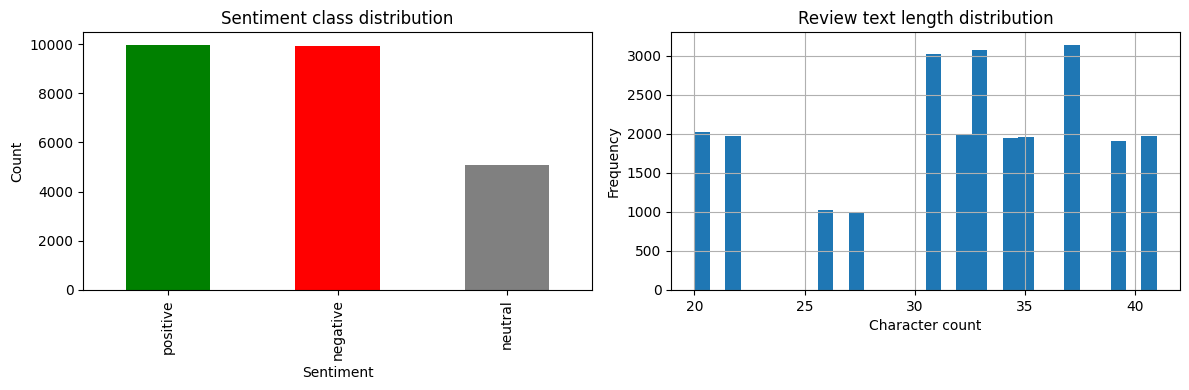

count    25000.000000
mean        32.061320
std          6.043527
min         20.000000
25%         31.000000
50%         33.000000
75%         37.000000
max         41.000000
Name: review_length, dtype: float64


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar chart
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'gray'])
axes[0].set_title('Sentiment class distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Review text length distribution
df['review_length'] = df['review_text'].str.len()
df['review_length'].hist(bins=30, ax=axes[1])
axes[1].set_title('Review text length distribution')
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(df['review_length'].describe())

In [12]:
import pandas as pd

# Cross-tab: does star rating align with sentiment label?
print(pd.crosstab(df['customer_rating'], df['sentiment']))

# Quick check: average rating per sentiment class
print("\nAverage rating by sentiment:")
print(df.groupby('sentiment')['customer_rating'].mean().round(2))

sentiment        negative  neutral  positive
customer_rating                             
1                    4891        0         0
2                    5046        0         0
3                       0     5085         0
4                       0        0      5066
5                       0        0      4912

Average rating by sentiment:
sentiment
negative    1.51
neutral     3.00
positive    4.49
Name: customer_rating, dtype: float64


In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # collapse extra whitespace
    return text

df['review_text_clean'] = df['review_text'].apply(clean_text)

# Quick check: before vs after
print(df[['review_text', 'review_text_clean']].head())

                               review_text  \
0      very disappointed with the quality.   
1       fast delivery and great packaging.   
2      very disappointed with the quality.   
3  product stopped working after few days.   
4               neutral about the quality.   

                        review_text_clean  
0      very disappointed with the quality  
1       fast delivery and great packaging  
2      very disappointed with the quality  
3  product stopped working after few days  
4               neutral about the quality  


In [14]:
from sklearn.model_selection import train_test_split

X = df['review_text_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))

Train size: 20000
Test size: 5000

Train class balance:
sentiment
positive    0.399
negative    0.398
neutral     0.203
Name: proportion, dtype: float64


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)  # transform only, not fit — avoids leakage

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("Sample feature names:", vectorizer.get_feature_names_out()[:20])

TF-IDF matrix shape (train): (20000, 36)
Sample feature names: ['amazing' 'average' 'better' 'customer' 'days' 'decent' 'delivery'
 'disappointed' 'exceeded' 'excellent' 'expectations' 'experience' 'fast'
 'fine' 'great' 'highly' 'late' 'money' 'neutral' 'okay']


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: ['negative' 'neutral' 'positive']


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1987
     neutral       1.00      1.00      1.00      1017
    positive       1.00      1.00      1.00      1996

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



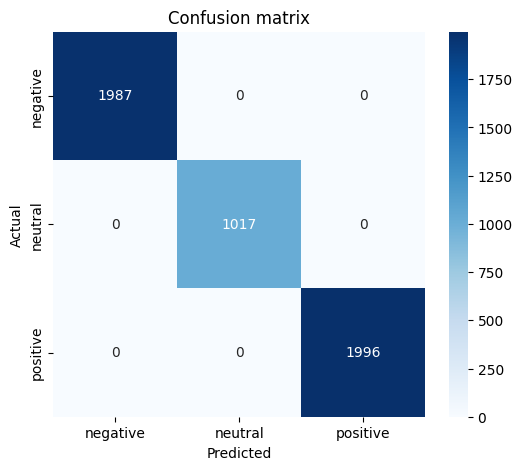

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

In [18]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

# For each class, show the top 10 words most associated with it
for i, class_name in enumerate(model.classes_):
    top_indices = np.argsort(model.coef_[i])[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"Top words for '{class_name}':", top_words)

Top words for 'negative': ['disappointed', 'late', 'poor', 'worth', 'price', 'days', 'working', 'stopped', 'customer', 'unhelpful']
Top words for 'neutral': ['neutral', 'fine', 'overall', 'average', 'special', 'okay', 'decent', 'works', 'better', 'product']
Top words for 'positive': ['satisfied', 'great', 'fast', 'excellent', 'expectations', 'exceeded', 'highly', 'recommend', 'amazing', 'money']


In [19]:
from collections import Counter

# Filter to negative reviews only
negative_reviews = df[df['sentiment'] == 'negative']['review_text_clean']

# Combine all negative review text and count word frequency
all_words = ' '.join(negative_reviews).split()

# Remove common stopwords manually (simple list, since text is short)
stopwords = {'the', 'a', 'an', 'is', 'was', 'were', 'with', 'to', 'of', 'and', 'i', 'it', 'this', 'my'}
filtered_words = [w for w in all_words if w not in stopwords]

word_freq = Counter(filtered_words)
print("Top 20 words in negative reviews:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

Top 20 words in negative reviews:
  late: 2044
  delivery: 2044
  poor: 2044
  packaging: 2044
  not: 2026
  worth: 2026
  price: 2026
  customer: 2007
  service: 2007
  unhelpful: 2007
  very: 1952
  disappointed: 1952
  quality: 1952
  product: 1908
  stopped: 1908
  working: 1908
  after: 1908
  few: 1908
  days: 1908


In [20]:
# Which product categories generate the most negative reviews?
negative_by_category = df[df['sentiment'] == 'negative']['product_category'].value_counts()
print("Negative reviews by product category:")
print(negative_by_category)

# As a percentage of that category's total reviews (fairer comparison)
category_negative_rate = df.groupby('product_category').apply(
    lambda x: (x['sentiment'] == 'negative').mean() * 100
).round(1).sort_values(ascending=False)
print("\nNegative review rate by product category (%):")
print(category_negative_rate)

Negative reviews by product category:
product_category
fashion           1148
books             1141
home & kitchen    1134
automobile        1126
groceries         1108
beauty            1104
travel            1066
electronics       1061
sports            1049
Name: count, dtype: int64

Negative review rate by product category (%):
product_category
home & kitchen    41.6
fashion           41.3
beauty            41.0
books             40.6
automobile        39.7
electronics       38.9
groceries         38.8
sports            38.0
travel            37.9
dtype: float64


/tmp/ipykernel_3876/1014493386.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_negative_rate = df.groupby('product_category').apply(


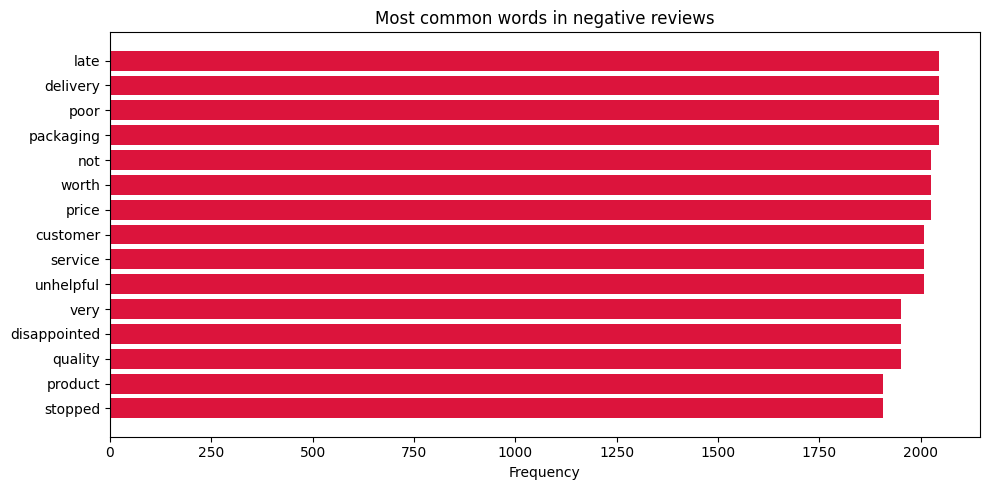

In [21]:
import matplotlib.pyplot as plt

top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='crimson')
plt.title('Most common words in negative reviews')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()